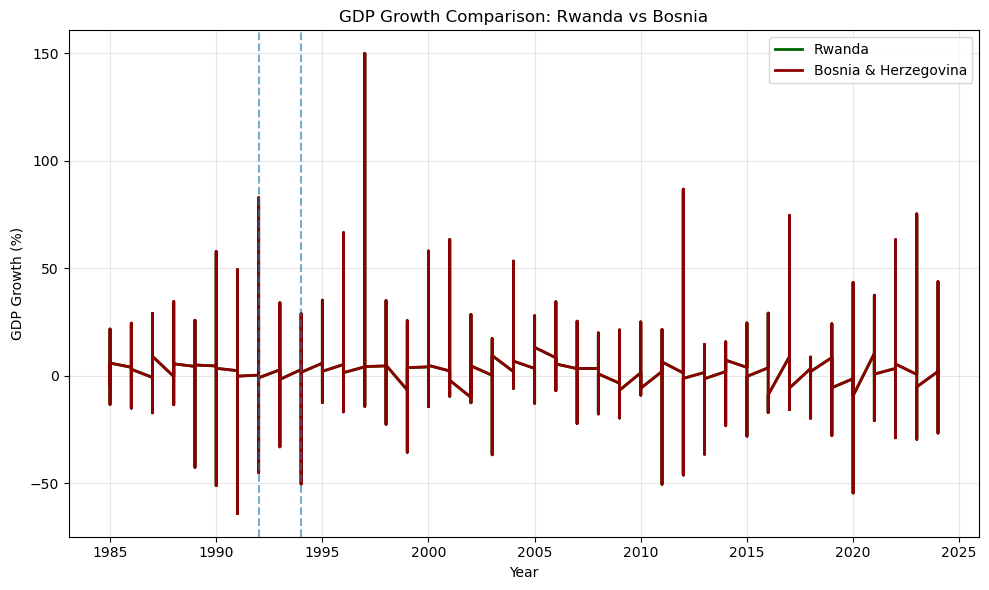

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------- FUNCTION TO LOAD WORLD BANK DATA ----------
def load_worldbank(filepath):
    df = pd.read_csv(filepath, skiprows=4)

    df = df.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        var_name="Year",
        value_name="GDP Growth"
    )

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df["GDP Growth"] = pd.to_numeric(df["GDP Growth"], errors="coerce")

    df = df.dropna(subset=["GDP Growth"])
    df = df.sort_values("Year")

    return df


# ---------- LOAD DATA ----------
rwanda = load_worldbank("../data/rwanda_gdp_growth.csv")
bosnia = load_worldbank("../data/bosnia_gdp_growth.csv")


# ---------- OPTIONAL: FOCUS ON RELEVANT YEARS ----------
rwanda = rwanda[rwanda["Year"] >= 1985]
bosnia = bosnia[bosnia["Year"] >= 1985]


# ---------- PLOT ----------
plt.figure(figsize=(10, 6))

plt.plot(
    rwanda["Year"],
    rwanda["GDP Growth"],
    label="Rwanda",
    color="darkgreen",
    linewidth=2
)

plt.plot(
    bosnia["Year"],
    bosnia["GDP Growth"],
    label="Bosnia & Herzegovina",
    color="darkred",
    linewidth=2
)

# Conflict markers
plt.axvline(x=1994, linestyle="--", alpha=0.6)  # Rwanda genocide
plt.axvline(x=1992, linestyle="--", alpha=0.6)  # Bosnia war start

plt.title("GDP Growth Comparison: Rwanda vs Bosnia")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
